In [ ]:
!pip install rasterio

In [ ]:
import time
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score, precision_score, recall_score)
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

In [ ]:
csv_path = "/content/drive/MyDrive/GEE_Exports/glacial_lake_dataset.csv"

In [ ]:
feature_cols = [
    "Blue", "Green", "Red", "NIR", "SWIR1", "SWIR2",
    "NDWI", "NDSI", "MNDWI", "NDWI_blue",
    "Slope", "Hillshade", "Elevation"
]

In [ ]:
label_col = "label"
random_state = 42

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv(csv_path)

In [ ]:
df.head()

,Band_1,Band_2,Band_3,Band_4,Band_5,Band_6,Band_7,Band_8,Band_9,Band_10,Band_11,Slope,Hillshade,Elevation,label,AOI
0,0.36150,0.37225,0.31695,0.29870,0.08385,0.07200,0.109621,0.632316,1.570791,0.0,122.564682,89.999710,69.299384,122.564682,0,barlacha
1,0.39760,0.42795,0.37685,0.33700,0.06850,0.05905,0.118896,0.724039,1.570791,0.0,100.333435,89.999718,87.277087,100.333435,0,barlacha
2,0.42280,0.42750,0.38225,0.36220,0.14865,0.13720,0.082690,0.483988,1.570789,0.0,120.702019,89.999596,4.041860,120.702019,0,barlacha
3,0.39645,0.41710,0.37845,0.33760,0.11250,0.10895,0.105340,0.575150,1.570791,0.0,113.053612,89.999687,45.456524,113.053612,0,barlacha
4,0.37290,0.39820,0.35910,0.31595,0.11250,0.10895,0.115172,0.559427,1.570792,0.0,96.766403,89.999748,39.132074,96.766403,0,barlacha


In [ ]:
df.columns

Index(['Band_1', 'Band_2', 'Band_3', 'Band_4', 'Band_5', 'Band_6', 'Band_7',
       'Band_8', 'Band_9', 'Band_10', 'Band_11', 'Slope', 'Hillshade',
       'Elevation', 'label', 'AOI'],
      dtype='object')

In [ ]:
df['label'].value_counts()

,count
label,
1,2047237
0,14933


In [ ]:
df = df.rename(columns={
    "Band_1": "Blue",
    "Band_2": "Green",
    "Band_3": "Red",
    "Band_4": "NIR",
    "Band_5": "SWIR1",
    "Band_6": "SWIR2",
    "Band_7": "NDWI",
    "Band_8": "NDSI",
    "Band_9": "MNDWI",
    "Band_10": "NDWI_blue"
})

In [ ]:
df.head()

,Blue,Green,Red,NIR,SWIR1,SWIR2,NDWI,NDSI,MNDWI,NDWI_blue,Band_11,Slope,Hillshade,Elevation,label,AOI
0,0.36150,0.37225,0.31695,0.29870,0.08385,0.07200,0.109621,0.632316,1.570791,0.0,122.564682,89.999710,69.299384,122.564682,0,barlacha
1,0.39760,0.42795,0.37685,0.33700,0.06850,0.05905,0.118896,0.724039,1.570791,0.0,100.333435,89.999718,87.277087,100.333435,0,barlacha
2,0.42280,0.42750,0.38225,0.36220,0.14865,0.13720,0.082690,0.483988,1.570789,0.0,120.702019,89.999596,4.041860,120.702019,0,barlacha
3,0.39645,0.41710,0.37845,0.33760,0.11250,0.10895,0.105340,0.575150,1.570791,0.0,113.053612,89.999687,45.456524,113.053612,0,barlacha
4,0.37290,0.39820,0.35910,0.31595,0.11250,0.10895,0.115172,0.559427,1.570792,0.0,96.766403,89.999748,39.132074,96.766403,0,barlacha


In [ ]:
df = df.drop(columns=['Band_11'])

In [ ]:
df.head()

,Blue,Green,Red,NIR,SWIR1,SWIR2,NDWI,NDSI,MNDWI,NDWI_blue,Slope,Hillshade,Elevation,label,AOI
0,0.36150,0.37225,0.31695,0.29870,0.08385,0.07200,0.109621,0.632316,1.570791,0.0,89.999710,69.299384,122.564682,0,barlacha
1,0.39760,0.42795,0.37685,0.33700,0.06850,0.05905,0.118896,0.724039,1.570791,0.0,89.999718,87.277087,100.333435,0,barlacha
2,0.42280,0.42750,0.38225,0.36220,0.14865,0.13720,0.082690,0.483988,1.570789,0.0,89.999596,4.041860,120.702019,0,barlacha
3,0.39645,0.41710,0.37845,0.33760,0.11250,0.10895,0.105340,0.575150,1.570791,0.0,89.999687,45.456524,113.053612,0,barlacha
4,0.37290,0.39820,0.35910,0.31595,0.11250,0.10895,0.115172,0.559427,1.570792,0.0,89.999748,39.132074,96.766403,0,barlacha


In [ ]:
rf_params = dict(
    n_estimators=150,
    max_depth=20,
    max_features="sqrt",
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=random_state,
    n_jobs=-1
)

Ratios for Testing

In [ ]:
ratios = [1, 2, 3]

In [ ]:
lake_df = df[df[label_col] == 1].copy()
nonlake_df = df[df[label_col] == 0].copy()
print("Original counts -> lake:", len(lake_df), " non-lake:", len(nonlake_df))

Original counts -> lake: 2047237  non-lake: 14933


# Experiment

In [ ]:
results = []

In [ ]:
for r in ratios:
    print("\n" + "="*60)
    print(f"Ratio 1:{r} (lake:nonlake = 1:{r}) experiment starting")
    start_time = time.time()

    total_nonlake = len(nonlake_df)
    total_lake = len(lake_df)

    # Sample lakes proportional to non-lake count * r
    lake_sample_n = min(total_lake, total_nonlake * r)
    lake_sampled = lake_df.sample(n=lake_sample_n, random_state=random_state)

    # Combine lake + all non-lake
    combined = pd.concat([lake_sampled, nonlake_df], ignore_index=True)

    # Compute target non-lake count (lake_sample_n * r)
    nonlake_target = lake_sample_n * r
    current_nonlake = (combined[label_col] == 0).sum()

    print(f"lake_sample_n={lake_sample_n}, current_nonlake={current_nonlake}, nonlake_target={nonlake_target}")

    X = combined[feature_cols].values
    y = combined[label_col].values

    # If non-lake are fewer than target -> oversample with SMOTE
    if current_nonlake < nonlake_target:
        delta = nonlake_target - current_nonlake
        print(f"-> Augmenting non-lake by SMOTE to reach {nonlake_target} (adding {delta})")
        smote = SMOTE(sampling_strategy={0: nonlake_target}, random_state=random_state)
        X_res, y_res = smote.fit_resample(X, y)
    else:
        print("-> No augmentation needed.")
        X_res, y_res = X, y

    # Final class distribution
    unique, counts = np.unique(y_res, return_counts=True)
    dist = dict(zip(unique, counts))
    print("After augmentation class counts:", dist)

    # --------------------------
    # Train/Validation split
    # --------------------------
    X_train, X_val, y_train, y_val = train_test_split(
        X_res, y_res, test_size=0.3, stratify=y_res, random_state=random_state
    )

    # --------------------------
    # Train RF
    # --------------------------
    rf = RandomForestClassifier(**rf_params)
    t0 = time.time()
    rf.fit(X_train, y_train)
    t1 = time.time()
    train_time = t1 - t0

    # --------------------------
    # Evaluation
    # --------------------------
    y_pred = rf.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)

    cm = confusion_matrix(y_val, y_pred)
    report_str = classification_report(y_val, y_pred, digits=4)

    elapsed = time.time() - start_time

    print(f"Results (1:{r}) -> acc={acc:.4f}, f1={f1:.4f}, prec={prec:.4f}, rec={rec:.4f}")
    print("Confusion matrix:\n", cm)
    print("Classification report:\n", report_str)

    results.append({
    "ratio": r,
    "lake_sample_n": lake_sample_n,
    "nonlake_target": nonlake_target,
    "class_counts": dist,
    "accuracy": acc,
    "f1": f1,
    "precision": prec,
    "recall": rec,
    "train_time_s": train_time,
    "total_time_s": elapsed,
    "clf": rf   # <--- save the trained model
})


Ratio 1:1 (lake:nonlake = 1:1) experiment starting
lake_sample_n=14933, current_nonlake=14933, nonlake_target=14933
-> No augmentation needed.
After augmentation class counts: {np.int64(0): np.int64(14933), np.int64(1): np.int64(14933)}
Results (1:1) -> acc=0.8836, f1=0.8805, prec=0.9043, rec=0.8580
Confusion matrix:
 [[4073  407]
 [ 636 3844]]
Classification report:
               precision    recall  f1-score   support

           0     0.8649    0.9092    0.8865      4480
           1     0.9043    0.8580    0.8805      4480

    accuracy                         0.8836      8960
   macro avg     0.8846    0.8836    0.8835      8960
weighted avg     0.8846    0.8836    0.8835      8960


Ratio 1:2 (lake:nonlake = 1:2) experiment starting
lake_sample_n=29866, current_nonlake=14933, nonlake_target=59732
-> Augmenting non-lake by SMOTE to reach 59732 (adding 44799)
After augmentation class counts: {np.int64(0): np.int64(59732), np.int64(1): np.int64(29866)}
Results (1:2) -> acc=0.9089,

In [ ]:
res_df = pd.DataFrame(results)
print("\n=== Summary ===")
print(res_df)


=== Summary ===
   ratio  lake_sample_n  nonlake_target           class_counts  accuracy  \
0      1          14933           14933   {0: 14933, 1: 14933}  0.883594   
1      2          29866           59732   {0: 59732, 1: 29866}  0.908891   
2      3          44799          134397  {0: 134397, 1: 44799}  0.929575   

         f1  precision    recall  train_time_s  total_time_s  \
0  0.880541   0.904258  0.858036      9.664686     10.011554   
1  0.862470   0.867978  0.857031     41.333411     42.225750   
2  0.858202   0.864027  0.852455     94.976483     97.109625   

                                                 clf  
0  (DecisionTreeClassifier(max_depth=20, max_feat...  
1  (DecisionTreeClassifier(max_depth=20, max_feat...  
2  (DecisionTreeClassifier(max_depth=20, max_feat...  


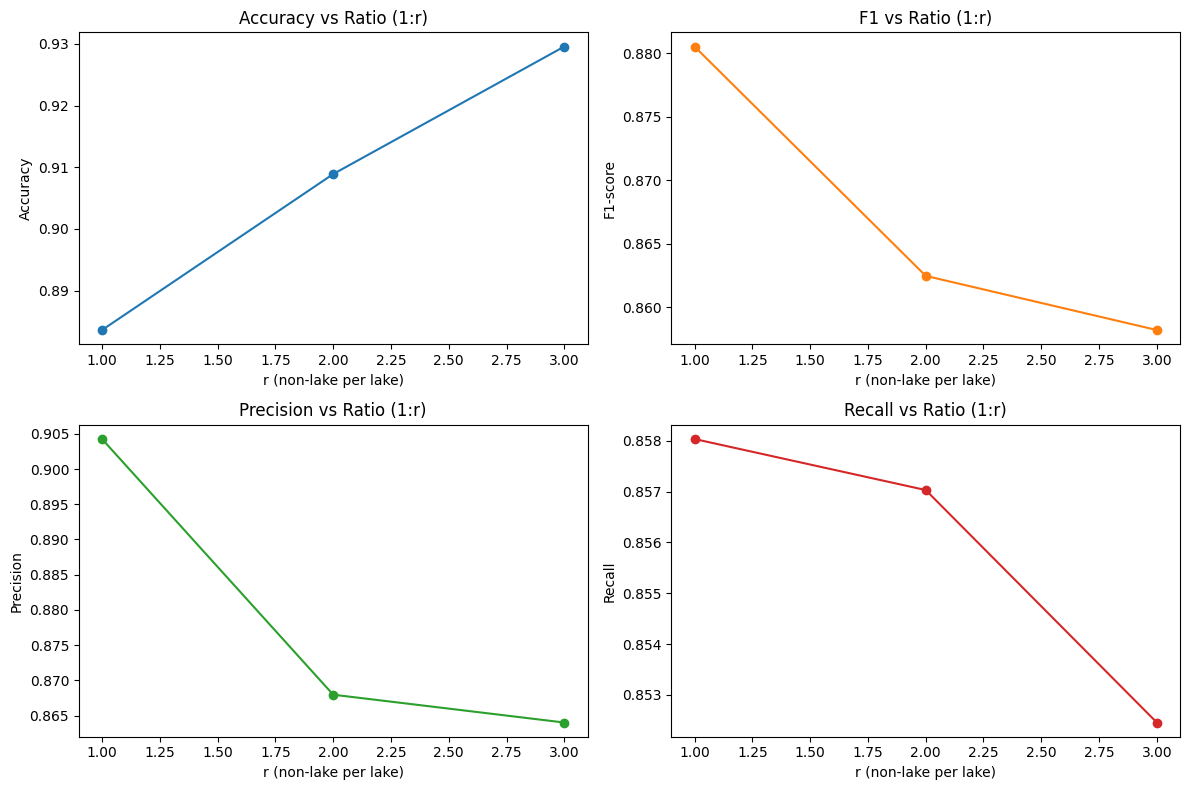

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Flatten so we can access them as a list
axes = axes.flatten()

axes[0].plot(res_df["ratio"], res_df["accuracy"], marker='o')
axes[0].set_title("Accuracy vs Ratio (1:r)")
axes[0].set_xlabel("r (non-lake per lake)")
axes[0].set_ylabel("Accuracy")

axes[1].plot(res_df["ratio"], res_df["f1"], marker='o', color='tab:orange')
axes[1].set_title("F1 vs Ratio (1:r)")
axes[1].set_xlabel("r (non-lake per lake)")
axes[1].set_ylabel("F1-score")

axes[2].plot(res_df["ratio"], res_df["precision"], marker='o', color='tab:green')
axes[2].set_title("Precision vs Ratio (1:r)")
axes[2].set_xlabel("r (non-lake per lake)")
axes[2].set_ylabel("Precision")

axes[3].plot(res_df["ratio"], res_df["recall"], marker='o', color='tab:red')
axes[3].set_title("Recall vs Ratio (1:r)")
axes[3].set_xlabel("r (non-lake per lake)")
axes[3].set_ylabel("Recall")

plt.tight_layout()
plt.show()

1:1 ratio → Best F1, Precision, Recall (good for detecting lakes).

1:3 ratio → Best Accuracy (good for background mapping, but misses some lakes).

Trade-off:
* If our goal is finding all lakes reliably, stick closer to 1:1 or 1:2.
* If we care about overall AOI classification correctness, 1:3 gives better accuracy but risks under-detecting lakes.